# End-to-End Web Scraping & Analysis Project: Flipkart Product laptops Price Analysis
#                             Project Objective
- The goal of this project is to extract product data such as laptops from Flipkart using web scraping - techniques, clean and structure the data using Python, and perform analysis to derive meaningful insights about pricing, ratings, and  - - product trends
___

# Workflow Overview

# Data Collection → Data Understanding → Data Cleaning → Data Visualization → Insights

---

# step→1. Data Collection (Web Scraping)
 - We used 'Python' libraries like 'requests' and 'BeautifulSoup' to scrape product data from multiple pages of Flipkart.
# Key Tasks:
- Sent HTTP GET requests to Flipkart search pages.
- Parsed HTML content using BeautifulSoup.
# Extracted:
 - Product Name
 - Price
 - Rating
 - (Optional) Discount, Reviews
___

In [142]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [143]:
product_name = []        
product_price = []      
product_rating = []      
product_rating_count=[]

product_brand = []      
product_processor = []   
product_ram = []         
product_storage = []     
product_display = []    

In [144]:
for i in range(1,6):
        url =f"https://www.flipkart.com/search?q=laptop&otracker=search&otxer1=search&marketplace=FLIPKART&as-show=on&as=off&p%5B%5D=facets.brand%255B%255D%3DHP&p%5B%5D=facets.brand%255B%255D%3DDELL&p%5B%5D=facets.brand%255B%255D%3DLenovo&p%5B%5D=facets.brand%255B%255D%3DASUS&p%5B%5D=facets.brand%255B%255D%3DAcer&sort=popularity&page={i}"
        request_header = { 
                      'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:126.0) Gecko/20100101 Firefox/126.0',
                    'Accept-Encoding': 'gzip, deflate, br, zstd'
                     }
    
        response = requests.get(url, headers=request_header)
        print(f"Status_code {i}: ", response.status_code)
    
        html_data = response.text
        # print(html_data)
        
        soup =BeautifulSoup(html_data)

        # Price
        price = soup.find_all("div", class_="hZ3P6w DeU9vF")
        for i in price:
            product_price.append(re.sub(r"\D", "", i.text))
        
        # Name
        name = soup.find_all("div", class_="RG5Slk")
        for i in name:
            product_name.append(i.text)
        
            # Extract Brand (first word)
            product_brand.append(i.text.split()[0])
        
        # Rating
        rating = soup.find_all("div", class_="MKiFS6")
        for i in rating:
            product_rating.append(i.text)

        # reviews
        review_tags = soup.find_all("span", class_="PvbNMB")

        for i in review_tags:
            product_rating_count.append(i.text)
            
        # Features
        features = soup.find_all("li", class_="DTBslk")
    
        for i in features:
            text = i.text
        
            if "Processor" in text:
                product_processor.append(text)
        
            elif "RAM" in text:
                product_ram.append(text)
        
            elif "SSD" in text or "HDD" in text:
                product_storage.append(text)
        
            elif "Display" in text:
                product_display.append(text)


    

Status_code 1:  200
Status_code 2:  200
Status_code 3:  200
Status_code 4:  200
Status_code 5:  200


In [145]:
print("product_name", len(product_name))
print("product_price", len(product_price))
print("product_processor", len (product_processor))
print("product_ram", len(product_ram))
print("product_storage",len(product_storage))
print("product_display",len(product_display))
print("product_rating",len(product_rating))
print("product_rating_count",len(product_rating_count))

product_name 120
product_price 120
product_processor 120
product_ram 120
product_storage 112
product_display 120
product_rating 118
product_rating_count 118


In [146]:
min_len=min(len(product_name),
            len(product_price),
            len(product_processor),
            len(product_ram),
            len(product_storage),
            len(product_display),
            len(product_rating),
           len(product_rating_count))

In [147]:
min_len

112

In [148]:
df=pd.DataFrame({"product_name":product_name[:min_len],
                "product_price":product_price[:min_len],
                "product_processor":product_processor[:min_len],
                "product_ram":product_ram[:min_len],
                "product_storage":product_storage[:min_len],
                "product_display":product_display[:min_len],
                "product_rating":product_rating[:min_len],
                "product_rating_count":product_rating_count[:min_len]})

In [149]:
df

,product_name,product_price,product_processor,product_ram,product_storage,product_display,product_rating,product_rating_count
0,ASUS Vivobook Go 15 AMD Ryzen 5 Quad Core 7520...,38990,AMD Ryzen 5 Quad Core Processor,8 GB LPDDR5 RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,4.3,"1,526 Ratings & 76 Reviews"
1,DELL Inspiron 5440 (2026) (i3 14th Gen) Intel ...,39699,Intel Core 3 Processor (14th Gen),8 GB DDR5 RAM,512 GB SSD,35.56 cm (14 inch) Display,3.8,28 Ratings & 5 Reviews
2,Acer Aspire Intel Core i3 13th Gen 1305U - (8 ...,38938,Intel Core i3 Processor (13th Gen),8 GB DDR4 RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,4,72 Ratings & 8 Reviews
3,Acer TravelLite AMD Ryzen 5 7430U - (8 GB/512 ...,40990,AMD Ryzen 5 Processor,8 GB DDR4 RAM,512 GB SSD,35.56 cm (14 Inch) Display,3.8,124 Ratings & 11 Reviews
4,Acer Aspire 3 Intel Celeron Dual Core - (8 GB/...,29999,Intel Celeron Dual Core Processor,8 GB DDR4 RAM,128 GB SSD,29.46 cm (11.6 Inch) Display,3.8,"9,077 Ratings & 771 Reviews"
...,...,...,...,...,...,...,...,...
107,"ASUS Vivobook 15, with Backlit Keyboard, Intel...",35990,Intel Core i3 Processor (12th Gen),8 GB DDR4 RAM,1 TB SSD,39.62 cm (15.6 Inch) Display,4.2,"13,575 Ratings & 971 Reviews"
108,Lenovo LOQ Essential Intel Core i7 12650HX - (...,85990,Intel Core i7 Processor,16 GB DDR5 RAM,1 TB SSD,39.62 cm (15.6 Inch) Display,4.1,"2,408 Ratings & 207 Reviews"
109,Acer One Intel Core i3 11th Gen 1115G4 - (8 GB...,20999,Intel Core i3 Processor (11th Gen),8 GB DDR4 RAM,512 GB SSD,35.56 cm (14 Inch) Display,4.4,24 Ratings & 3 Reviews
110,Acer Aspire Lite Intel Core i5 12th Gen 12450H...,58548,Intel Core i5 Processor (12th Gen),16 GB LPDDR5 RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,4.2,"1,697 Ratings & 156 Reviews"


___
# step→2:Data Understanding
 - Once the raw data was scraped from Flipkart for laptops (Lenovo, HP, Dell, Acer), the dataset was examined to understand its structure and quality before proceeding to cleaning and analysis.

# Key Activities Performed:
 - Reviewed the dataset using functions like head(), info(), and describe() to understand the structure and data types of each column.
# Verified that all required columns were successfully extracted:
 - Product Name
 - Product Price
 - Processor
 - RAM
 - Storage
 - Display
 - Rating
 - rating count
# Checked for missing values:
 - Observed that most products had complete information
 - Some entries may have missing ratings depending on availability
# Identified data format consistency:
- Prices were already cleaned into numeric format (e.g., 38990, 69990)
- Ratings were in float format (e.g., 4.3, 3.9)
- Rating count were initially in combined format: "1,515 Ratings & 76 Reviews"
# Observed that product specifications such as:
- Processor
- RAM
- Storage
- Display
- are stored as text and are semi-structured, requiring parsing for deeper analysis.
- Verified that all columns have equal length , ensuring proper alignment and no data mismatch.
- Checked for duplicate or redundant entries to maintain dataset quality.
___

In [150]:
df.head()

,product_name,product_price,product_processor,product_ram,product_storage,product_display,product_rating,product_rating_count
0,ASUS Vivobook Go 15 AMD Ryzen 5 Quad Core 7520...,38990,AMD Ryzen 5 Quad Core Processor,8 GB LPDDR5 RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,4.3,"1,526 Ratings & 76 Reviews"
1,DELL Inspiron 5440 (2026) (i3 14th Gen) Intel ...,39699,Intel Core 3 Processor (14th Gen),8 GB DDR5 RAM,512 GB SSD,35.56 cm (14 inch) Display,3.8,28 Ratings & 5 Reviews
2,Acer Aspire Intel Core i3 13th Gen 1305U - (8 ...,38938,Intel Core i3 Processor (13th Gen),8 GB DDR4 RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,4,72 Ratings & 8 Reviews
3,Acer TravelLite AMD Ryzen 5 7430U - (8 GB/512 ...,40990,AMD Ryzen 5 Processor,8 GB DDR4 RAM,512 GB SSD,35.56 cm (14 Inch) Display,3.8,124 Ratings & 11 Reviews
4,Acer Aspire 3 Intel Celeron Dual Core - (8 GB/...,29999,Intel Celeron Dual Core Processor,8 GB DDR4 RAM,128 GB SSD,29.46 cm (11.6 Inch) Display,3.8,"9,077 Ratings & 771 Reviews"


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   product_name          112 non-null    object
 1   product_price         112 non-null    object
 2   product_processor     112 non-null    object
 3   product_ram           112 non-null    object
 4   product_storage       112 non-null    object
 5   product_display       112 non-null    object
 6   product_rating        112 non-null    object
 7   product_rating_count  112 non-null    object
dtypes: object(8)
memory usage: 7.1+ KB


In [152]:
df.describe()

,product_name,product_price,product_processor,product_ram,product_storage,product_display,product_rating,product_rating_count
count,112,112,112,112,112,112,112,112
unique,105,77,24,16,5,10,16,86
top,HP 255R G10 (2026) Professional DDR5 5600Mhz A...,40990,Intel Core i3 Processor (13th Gen),8 GB DDR4 RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,4.3,"1,526 Ratings & 76 Reviews"
freq,3,5,16,32,97,68,29,4


___
# step→3: Data Cleaning (Using Pandas & Regex)
- We used the pandas library to structure the scraped laptop dataset into a DataFrame and applied regular expressions (regex) to clean and transform the data into a usable format for analysis.
# Cleaning Steps:
- Removed unwanted characters and spaces
- Cleaned text fields by removing commas (,) and extra spaces.
- Ensured consistency across all columns.
- Extracted rating count from combined text using regex
- The product_rating_count column contained values like:
- "1,515 Ratings & 76 Reviews"
- Extracted only the ratings count (1515) using regex.
- Handled missing or invalid values
- Replaced missing values (if any) with NaN for consistency.
- Ensured no mismatched or empty entries in the dataset.
- Converted data types
- Converted:
- product_price → Integer
- product_rating → Float
- Ratings_Count → Integer
- This ensured the dataset is ready for numerical analysis.
- Dropped unnecessary columns
- Removed the original product_rating_count column after extracting useful numerical data.
# Outcome:
Converted raw scraped data into a clean and structured dataset
Extracted meaningful numerical values from text fields
Improved data quality and consistency
Prepared the dataset for visualization and analysis
___

In [153]:
import re
# Extract Brand from Product Name (SAFE)
df['Brand'] = df['product_name'].astype(str).apply(
    lambda x: x.split()[0] if x else None
)

# Extract Processor Type (i3, i5, i7, Ryzen etc.)
df['Processor_Type'] = df['product_processor'].astype(str).apply(
    lambda x: re.findall(r'(i[3579]|Ryzen \d+)', x)[0] if re.findall(r'(i[3579]|Ryzen \d+)', x) else None
)

# Extract RAM (only number)
df['RAM_GB'] = df['product_ram'].astype(str).apply(
    lambda x: int(re.findall(r'(\d+)', x)[0]) if re.findall(r'(\d+)', x) else None
)

# Extract Storage (only number)
df['Storage_GB'] = df['product_storage'].astype(str).apply(
    lambda x: int(re.findall(r'(\d+)', x)[0]) if re.findall(r'(\d+)', x) else None
)

# Extract Display Size (in inches)
df['Display_Inch'] = df['product_display'].astype(str).apply(
    lambda x: float(re.findall(r'(\d+\.\d+)', x)[0]) if re.findall(r'(\d+\.\d+)', x) else None
)

# Extract Ratings Count 
df['Ratings_Count'] = df['product_rating_count'].astype(str).apply(
    lambda x: int(re.search(r'(\d+,?\d*) Ratings', x).group(1).replace(",", "")) 
    if re.search(r'(\d+,?\d*) Ratings', x) else 0
)

# Clean Product Name (remove brackets part)
df['product_name'] = df['product_name'].astype(str).apply(
    lambda x: re.sub(r"\s*\(.*?\)", "", x)
)

In [154]:
df

,product_name,product_price,product_processor,product_ram,product_storage,product_display,product_rating,product_rating_count,Brand,Processor_Type,RAM_GB,Storage_GB,Display_Inch,Ratings_Count
0,ASUS Vivobook Go 15 AMD Ryzen 5 Quad Core 7520...,38990,AMD Ryzen 5 Quad Core Processor,8 GB LPDDR5 RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,4.3,"1,526 Ratings & 76 Reviews",ASUS,Ryzen 5,8,512,39.62,1526
1,DELL Inspiron 5440 Intel Core 3 14th Gen 100U ...,39699,Intel Core 3 Processor (14th Gen),8 GB DDR5 RAM,512 GB SSD,35.56 cm (14 inch) Display,3.8,28 Ratings & 5 Reviews,DELL,None,8,512,35.56,28
2,Acer Aspire Intel Core i3 13th Gen 1305U - AL1...,38938,Intel Core i3 Processor (13th Gen),8 GB DDR4 RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,4,72 Ratings & 8 Reviews,Acer,i3,8,512,39.62,72
3,Acer TravelLite AMD Ryzen 5 7430U - TL04-41M N...,40990,AMD Ryzen 5 Processor,8 GB DDR4 RAM,512 GB SSD,35.56 cm (14 Inch) Display,3.8,124 Ratings & 11 Reviews,Acer,Ryzen 5,8,512,35.56,124
4,Acer Aspire 3 Intel Celeron Dual Core - A311-4...,29999,Intel Celeron Dual Core Processor,8 GB DDR4 RAM,128 GB SSD,29.46 cm (11.6 Inch) Display,3.8,"9,077 Ratings & 771 Reviews",Acer,None,8,128,29.46,9077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,"ASUS Vivobook 15, with Backlit Keyboard, Intel...",35990,Intel Core i3 Processor (12th Gen),8 GB DDR4 RAM,1 TB SSD,39.62 cm (15.6 Inch) Display,4.2,"13,575 Ratings & 971 Reviews",ASUS,i3,8,1,39.62,13575
108,Lenovo LOQ Essential Intel Core i7 12650HX - (...,85990,Intel Core i7 Processor,16 GB DDR5 RAM,1 TB SSD,39.62 cm (15.6 Inch) Display,4.1,"2,408 Ratings & 207 Reviews",Lenovo,i7,16,1,39.62,2408
109,Acer One Intel Core i3 11th Gen 1115G4 - AO 14...,20999,Intel Core i3 Processor (11th Gen),8 GB DDR4 RAM,512 GB SSD,35.56 cm (14 Inch) Display,4.4,24 Ratings & 3 Reviews,Acer,i3,8,512,35.56,24
110,Acer Aspire Lite Intel Core i5 12th Gen 12450H...,58548,Intel Core i5 Processor (12th Gen),16 GB LPDDR5 RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,4.2,"1,697 Ratings & 156 Reviews",Acer,i5,16,512,39.62,1697


In [155]:
# Convert numeric columns
df['product_price'] = pd.to_numeric(df['product_price'], errors='coerce')
df['product_rating'] = pd.to_numeric(df['product_rating'], errors='coerce')
df['RAM_GB'] = pd.to_numeric(df['RAM_GB'], errors='coerce')
df['Storage_GB'] = pd.to_numeric(df['Storage_GB'], errors='coerce')
df['Display_Inch'] = pd.to_numeric(df['Display_Inch'], errors='coerce')
df['Ratings_Count'] = pd.to_numeric(df['Ratings_Count'], errors='coerce')

In [156]:
clean_df = df[[
    'Brand',
    'product_name',
    'product_price',
    'Processor_Type',
    'RAM_GB',
    'Storage_GB',
    'Display_Inch',
    'product_rating',
    'Ratings_Count'
]]

In [157]:
clean_df.columns = [
    'Brand',
    'Product_Name',
    'Price',
    'Processor',
    'RAM_GB',
    'Storage_GB',
    'Display_Inch',
    'Rating',
    'Ratings_Count'
]

In [158]:
clean_df.to_csv("Laptop_Data.csv", index=False)

In [159]:
df = pd.read_csv("Laptop_Data.csv")

In [160]:
df

,Brand,Product_Name,Price,Processor,RAM_GB,Storage_GB,Display_Inch,Rating,Ratings_Count
0,ASUS,ASUS Vivobook Go 15 AMD Ryzen 5 Quad Core 7520...,38990,Ryzen 5,8,512,39.62,4.3,1526
1,DELL,DELL Inspiron 5440 Intel Core 3 14th Gen 100U ...,39699,NaN,8,512,35.56,3.8,28
2,Acer,Acer Aspire Intel Core i3 13th Gen 1305U - AL1...,38938,i3,8,512,39.62,4.0,72
3,Acer,Acer TravelLite AMD Ryzen 5 7430U - TL04-41M N...,40990,Ryzen 5,8,512,35.56,3.8,124
4,Acer,Acer Aspire 3 Intel Celeron Dual Core - A311-4...,29999,NaN,8,128,29.46,3.8,9077
...,...,...,...,...,...,...,...,...,...
107,ASUS,"ASUS Vivobook 15, with Backlit Keyboard, Intel...",35990,i3,8,1,39.62,4.2,13575
108,Lenovo,Lenovo LOQ Essential Intel Core i7 12650HX - (...,85990,i7,16,1,39.62,4.1,2408
109,Acer,Acer One Intel Core i3 11th Gen 1115G4 - AO 14...,20999,i3,8,512,35.56,4.4,24
110,Acer,Acer Aspire Lite Intel Core i5 12th Gen 12450H...,58548,i5,16,512,39.62,4.2,1697


# step→4: Data Visualization (EDA)
- We used matplotlib and seaborn libraries to create visualizations for better understanding and analysis of the cleaned laptop dataset. These visualizations helped identify patterns, trends, and relationships between different features such as price, ratings, and - - -     -specifications.
# Univariate Analysis:
- Distribution of laptop ratings to understand overall product quality.
- Distribution of price ranges to identify common budget segments.
- Frequency of RAM configurations (e.g., 8GB, 16GB) among laptops.
- Distribution of storage capacities (e.g., 512GB, 1TB SSD).
# Bivariate Analysis:
- Relationship between ratings and ratings count (popularity).
- Comparison between price and rating to analyze value for money.
- Comparison of RAM vs price to understand pricing trends.
- Brand-wise comparison of ratings and popularity.
# Multivariate Analysis:
- Combined analysis of price, rating, and RAM/storage configurations.
- Analysis of how multiple features together influence laptop performance and popularity.
- Use of heatmaps to explore correlations between numerical variables such as:
- Price
- Rating
- Ratings_Count
- RAM
- Storage
# Outcome:
- Identified key trends in laptop pricing and specifications
- Understood relationship between product quality and popularity
- Enabled better comparison across brands and configurations
- Provided insights for decision-making and recommendation


In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

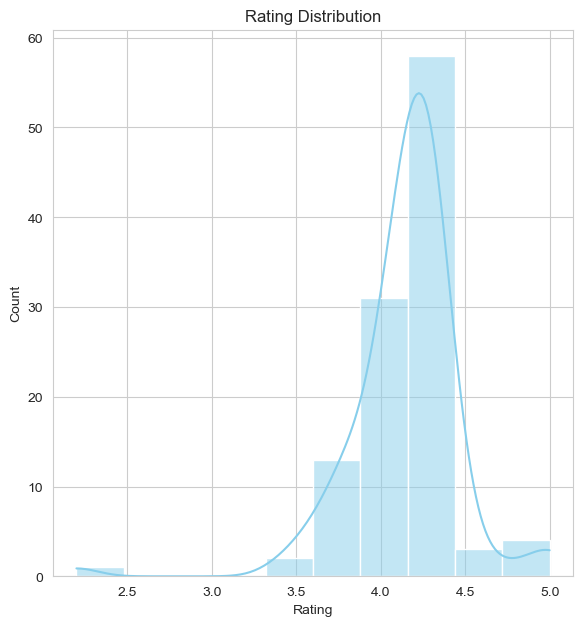

In [184]:
#  UNIVARIATE ANALYSIS
# 1. Rating Distribution
sns.set_style("whitegrid")
plt.figure(figsize=(22, 18))
plt.subplot(3, 4, 1)
sns.histplot(df['Rating'], bins=10, kde=True, color='skyblue')
plt.title("Rating Distribution")
plt.tight_layout()
plt.show()

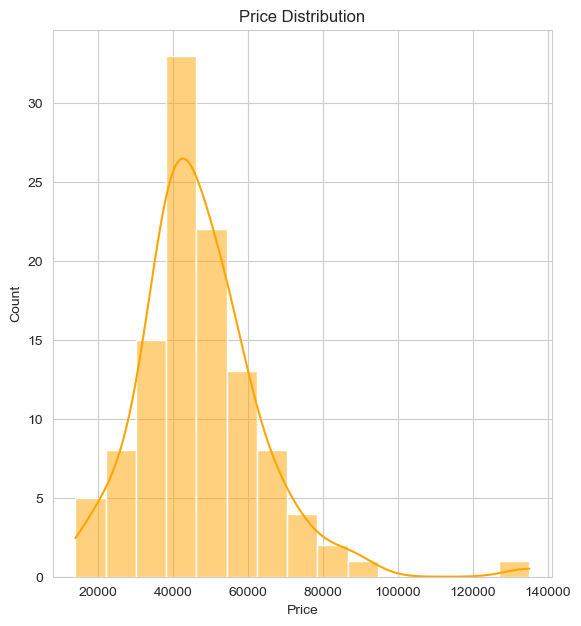

In [185]:
# 2. Price Distribution
sns.set_style("whitegrid")
plt.figure(figsize=(22, 18))
plt.subplot(3, 4, 2)
sns.histplot(df['Price'], bins=15, kde=True, color='orange')
plt.title("Price Distribution")
plt.tight_layout()
plt.show()

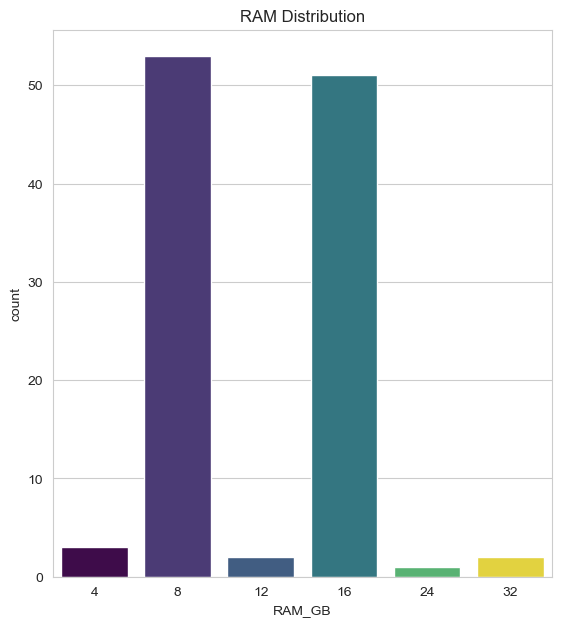

In [186]:
# 3. RAM Distribution
sns.set_style("whitegrid")
plt.figure(figsize=(22, 18))
plt.subplot(3, 4, 3)
sns.countplot(x='RAM_GB', data=df, hue='RAM_GB', palette='viridis', legend=False)
plt.title("RAM Distribution")
plt.tight_layout()
plt.show()

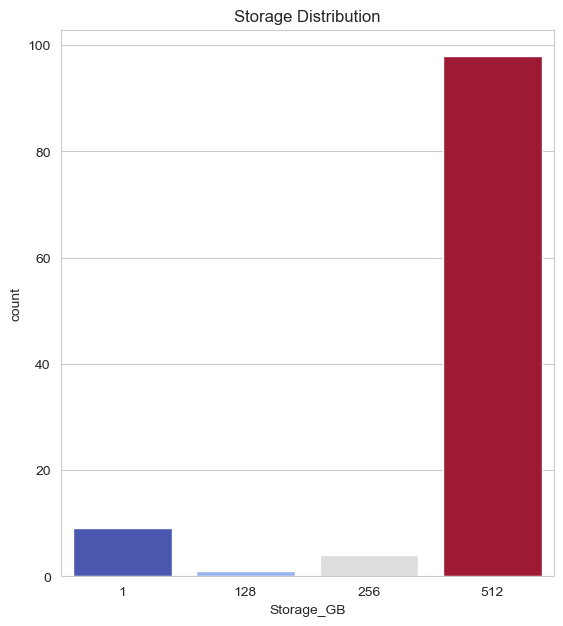

In [187]:
# 4. Storage Distribution
sns.set_style("whitegrid")
plt.figure(figsize=(22, 18))
plt.subplot(3, 4, 4)
sns.countplot(x='Storage_GB', data=df, hue='Storage_GB', palette='coolwarm', legend=False)
plt.title("Storage Distribution")
plt.tight_layout()
plt.show()

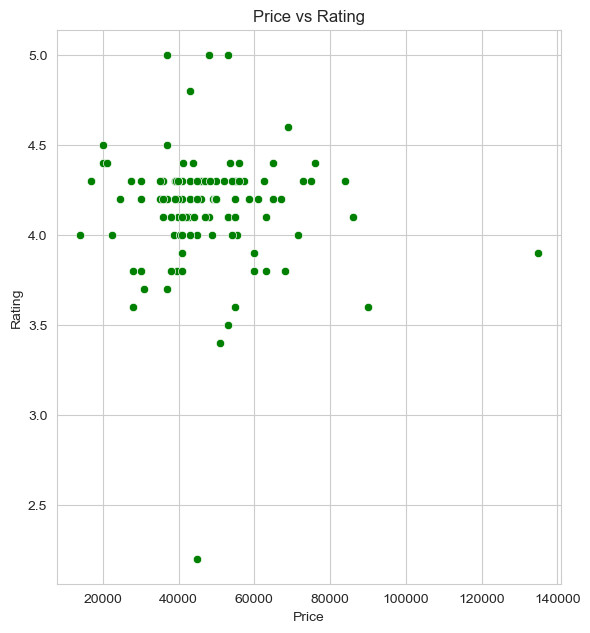

In [188]:
# BIVARIATE ANALYSIS

# 5. Price vs Rating
sns.set_style("whitegrid")
plt.figure(figsize=(22, 18))
plt.subplot(3, 4, 5)
sns.scatterplot(x='Price', y='Rating', data=df, color='green')
plt.title("Price vs Rating")
plt.tight_layout()
plt.show()

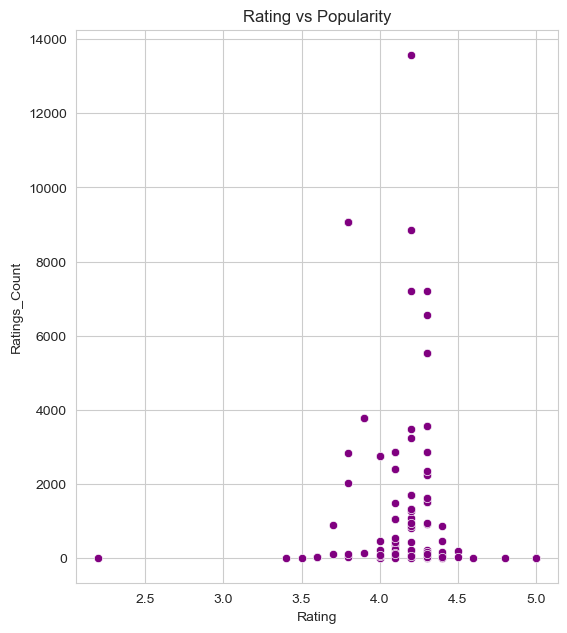

In [189]:
# 6. Rating vs Popularity
sns.set_style("whitegrid")
plt.figure(figsize=(22, 18))
plt.subplot(3, 4, 6)
sns.scatterplot(x='Rating', y='Ratings_Count', data=df, color='purple')
plt.title("Rating vs Popularity")
plt.tight_layout()
plt.show()

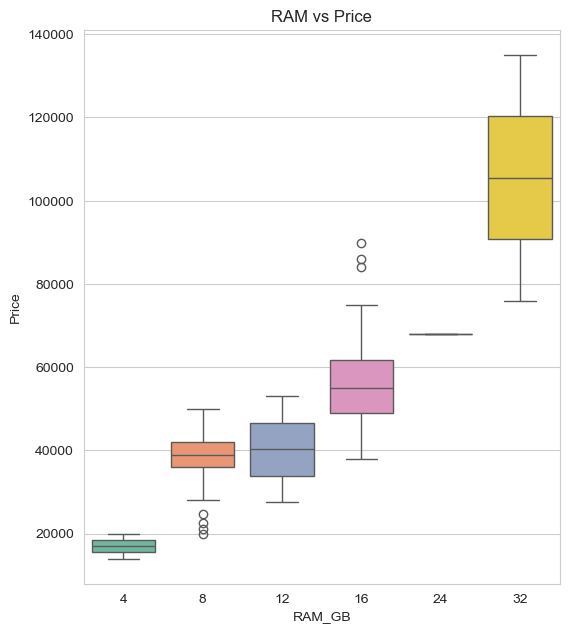

In [190]:
# 7. RAM vs Price
sns.set_style("whitegrid")
plt.figure(figsize=(22, 18))
plt.subplot(3, 4, 7)
sns.boxplot(x='RAM_GB', y='Price', data=df, hue='RAM_GB', palette='Set2', legend=False)
plt.title("RAM vs Price")
plt.tight_layout()
plt.show()


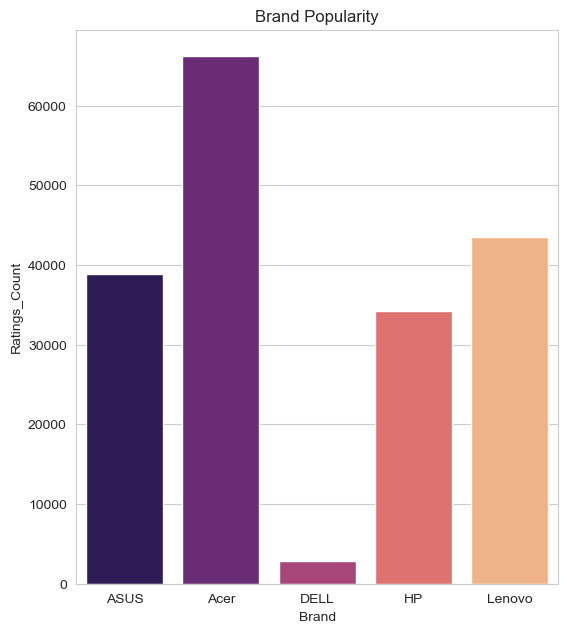

In [191]:
# 8. Brand-wise Popularity
sns.set_style("whitegrid")
plt.figure(figsize=(22, 18))
plt.subplot(3, 4, 8)
brand_sales = df.groupby('Brand')['Ratings_Count'].sum().reset_index()
sns.barplot(x='Brand', y='Ratings_Count', data=brand_sales, hue='Brand', palette='magma', legend=False)
plt.title("Brand Popularity")
plt.tight_layout()
plt.show()

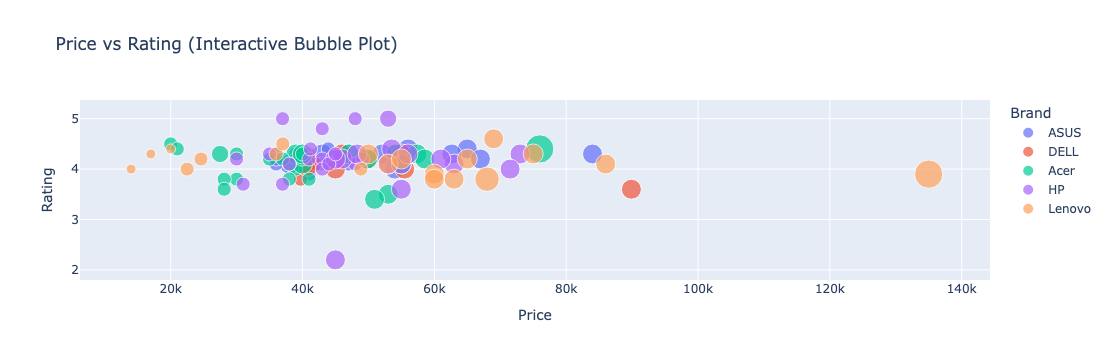

In [192]:

#  MULTIVARIATE ANALYSIS
#9.Price vs Rating (Interactive Bubble Plot)
# 9. Price vs Rating (Interactive Bubble Plot)
import plotly.express as px

fig = px.scatter(
    df,
    x="Price",
    y="Rating",
    size="RAM_GB",
    color="Brand",
    hover_data=["RAM_GB", "Storage_GB", "Ratings_Count", "Product_Name"],  # 🔥 hover info
    title="Price vs Rating (Interactive Bubble Plot)"
)

fig.show()

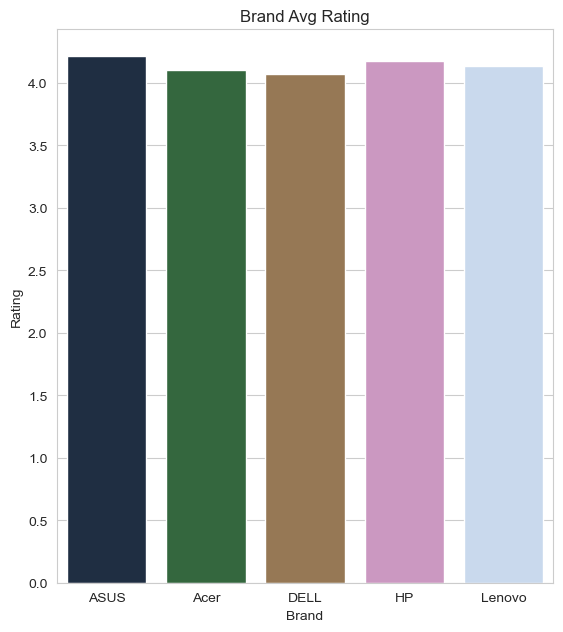

In [193]:
# 10. Brand-wise Average Rating
sns.set_style("whitegrid")
plt.figure(figsize=(22, 18))
plt.subplot(3, 4, 10)
brand_rating = df.groupby('Brand')['Rating'].mean().reset_index()
sns.barplot(x='Brand', y='Rating', data=brand_rating, hue='Brand', palette='cubehelix', legend=False)
plt.title("Brand Avg Rating")
plt.tight_layout()
plt.show()


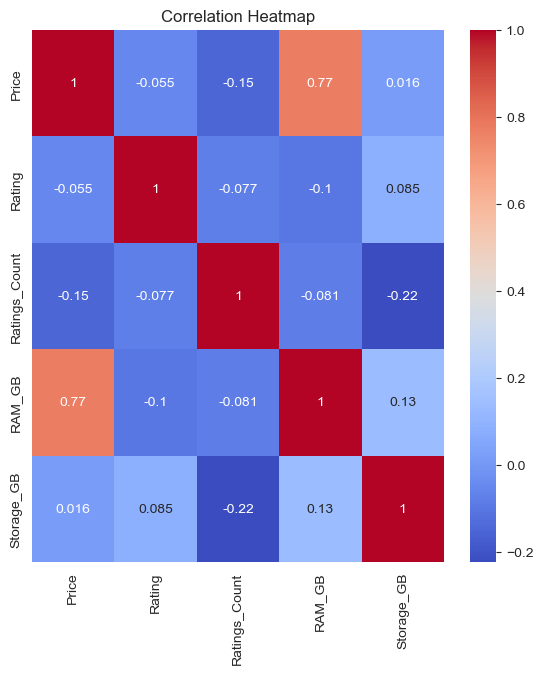

In [194]:
# 11. Correlation Heatmap
sns.set_style("whitegrid")
plt.figure(figsize=(22, 18))
plt.subplot(3, 4, 11)
corr = df[['Price', 'Rating', 'Ratings_Count', 'RAM_GB', 'Storage_GB']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

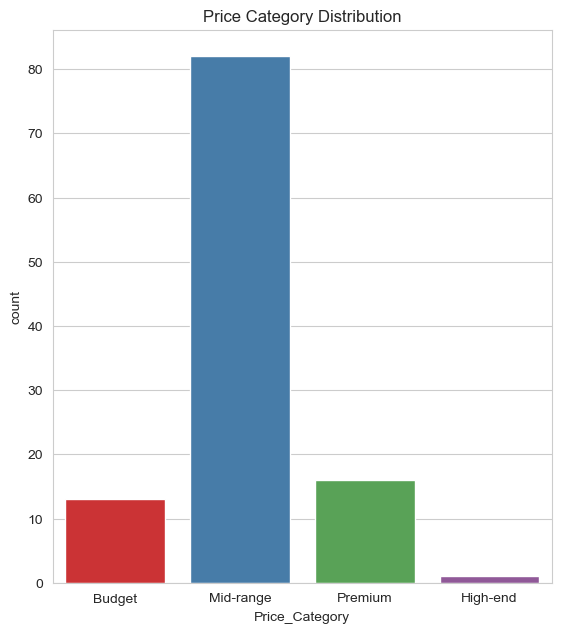

In [195]:
# 12. Price Category Analysis 
sns.set_style("whitegrid")
plt.figure(figsize=(22, 18))
df['Price_Category'] = pd.cut(
    df['Price'],
    bins=[0, 30000, 60000, 100000, 200000],
    labels=['Budget', 'Mid-range', 'Premium', 'High-end']
)

plt.subplot(3, 4, 12)
sns.countplot(x='Price_Category', data=df, hue='Price_Category', palette='Set1', legend=False)
plt.title("Price Category Distribution")

plt.tight_layout()
plt.show()

# 5. Insights & Observations

- Based on the analysis of the Flipkart laptop dataset, the following key insights:

# a.RAM & Storage Distribution:

- 8 GB RAM is the most common configuration, accounting for the majority of laptops.
- 512 GB SSD storage dominates the market, with a significant number of laptops also offering 1 TB SSD.
- High‑end configurations (16 GB RAM, 1 TB SSD) appear less frequently but command higher prices.
  
# b.Price Distribution:
- Laptop prices span a wide range from under ₹20,000 to over ₹1,00,000.
- A price category analysis shows that Budget (≤ ₹30,000) and Mid‑range (₹30,000–₹60,000) together represent the largest share, indicating that consumers prefer affordable to mid‑priced laptops.
  
# c.Brand Popularity (Total Ratings Count):
- Acer leads in total number of ratings, followed by HP and ASUS.
- High total ratings often correlate with a larger number of models and longer market presence.
  
# d.Average Ratings by Brand:
- Lenovo and ASUS show the highest average ratings (4.3–4.4), while brands like Acer and HP have slightly lower averages (4.0–4.2).
- Popularity (total ratings) does not always align with average rating—some popular brands have moderate average scores.
  
# e.Price vs. Rating Relationship:
- No strong linear correlation exists between price and rating.
- Laptops across all price segments can achieve high ratings, indicating that customer satisfaction depends on factors beyond price (e.g., build quality, performance, after‑sales service).
  
# f.RAM vs. Price:
- A clear positive trend: laptops with higher RAM (16 GB) are consistently more expensive than those with 8 GB, reflecting the premium for higher‑end specifications.
  
# g.Rating vs. Popularity (Ratings Count):
- A weak positive correlation suggests that products with more ratings (higher sales volume) tend to have slightly higher ratings, possibly due to more user feedback or established reputation.
  
# h.Correlation Heatmap:
- Price and RAM_GB show a moderate positive correlation (≈0.5), while Storage_GB has a weaker correlation with price.
- Rating exhibits negligible correlation with other numerical variables, reinforcing that product quality (as perceived by users) is influenced by many non‑quantified aspects.

# i.Price Category Distribution:

- Budget and Mid‑range categories together constitute the majority of the dataset.
Premium (₹60,000–₹1,00,000) and High‑end (above ₹1,00,000) form smaller segments, catering to niche performance‑oriented customers.

## Tools & Libraries Used:
- Python
- Requests (for HTTP requests)
- BeautifulSoup (for HTML parsing)
- Pandas (for data manipulation)
- Regex (for text extraction)
- Matplotlib, Seaborn & Plotly Express (for data visualization)